In [ ]:
!pip install snowflake-connector-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 7.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import snowflake.connector as sf
conn = sf.connect(
    user = "XXXX",
    password = "XXXXXX",
    account = 'XXXXXX',
    database = 'TITANIC',
    schema = 'PUBLIC',
    WAREHOUSE = 'COMPUTE_WH'
)

In [ ]:
import pandas as pd
query ="SELECT * FROM TITANIC"
df = pd.read_sql(query,conn)
df.head()

/tmp/ipykernel_6102/3006357883.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df.head()

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S


In [ ]:
df.isnull().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
NAME,0
SEX,0
AGE,177
SIBSP,0
PARCH,0
TICKET,0
FARE,0


In [ ]:
df['AGE'] = df['AGE'].fillna(df['AGE'].median())
df['CABIN'] = df['CABIN'].fillna(df['CABIN'].mode().iloc[0])
df['EMBARKED'] = df['EMBARKED'].fillna(df['EMBARKED'].mode().iloc[0])

In [ ]:
df.head(10)

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,B96 B98,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,B96 B98,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,B96 B98,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,B96 B98,C


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categ = df.select_dtypes(include = 'object')
for cols in categ:
  df[cols] = le.fit_transform(df[cols])
df.head()

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,108,1,22.0,1,0,523,7.2500,47,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,47,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.0,0,0,472,8.0500,47,2


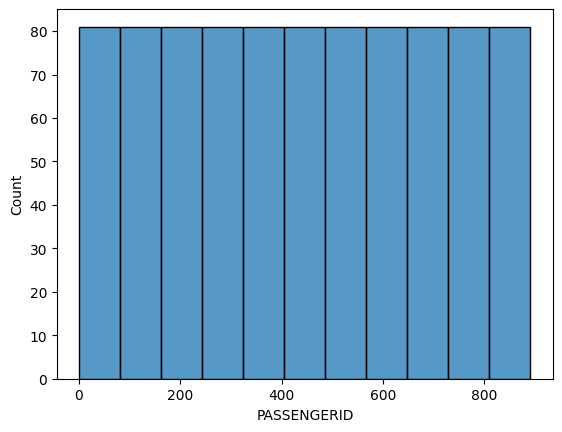

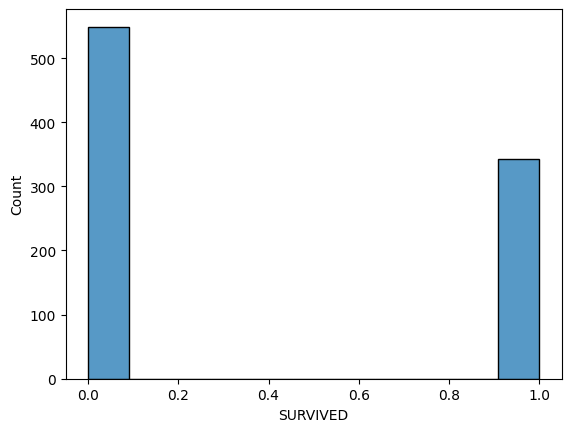

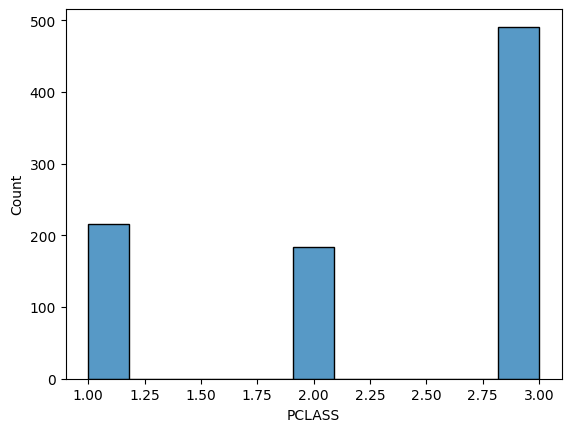

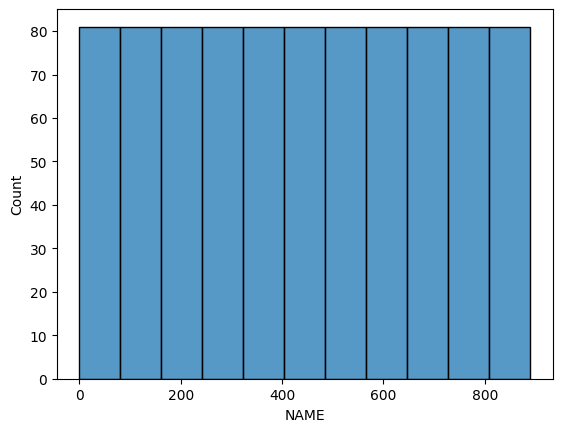

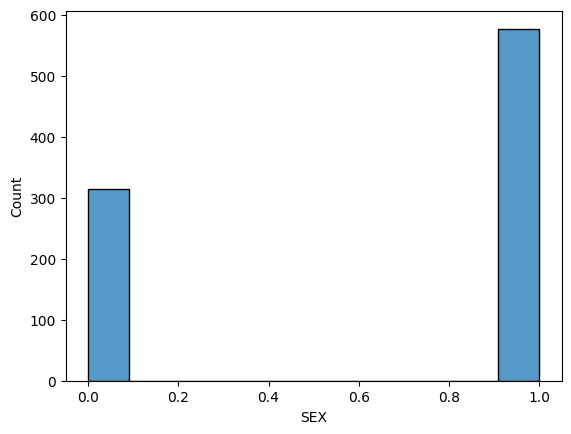

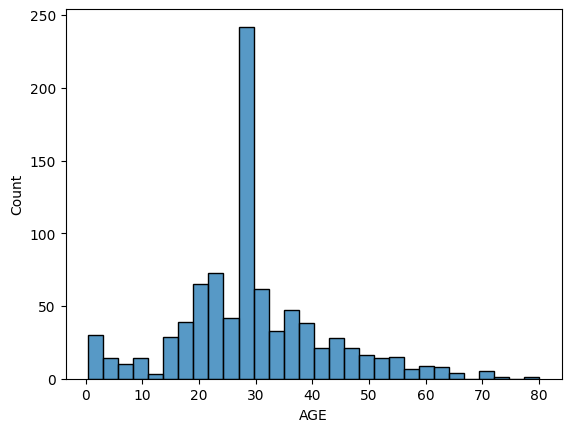

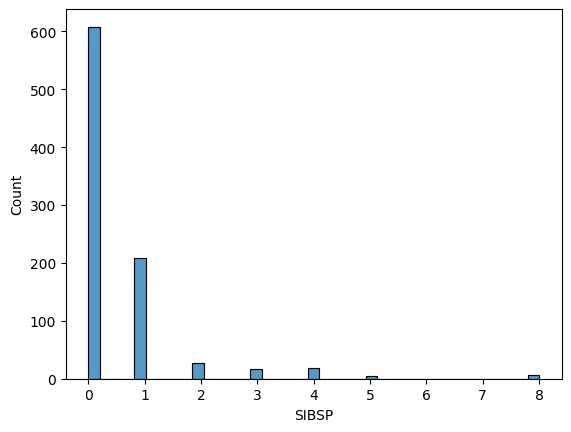

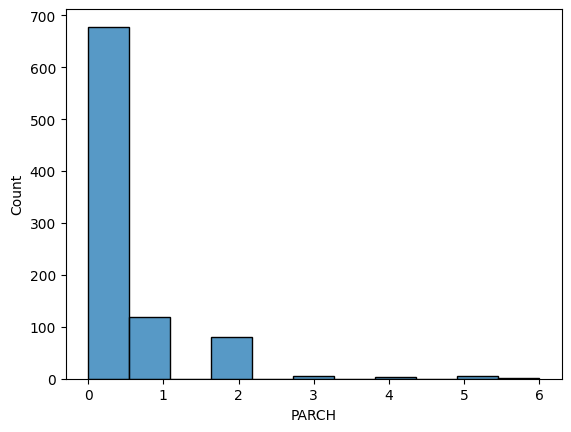

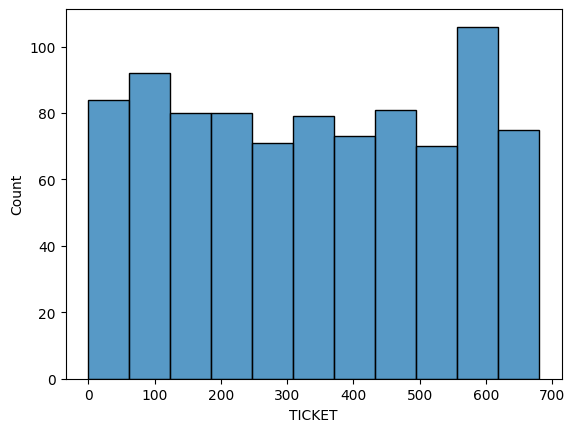

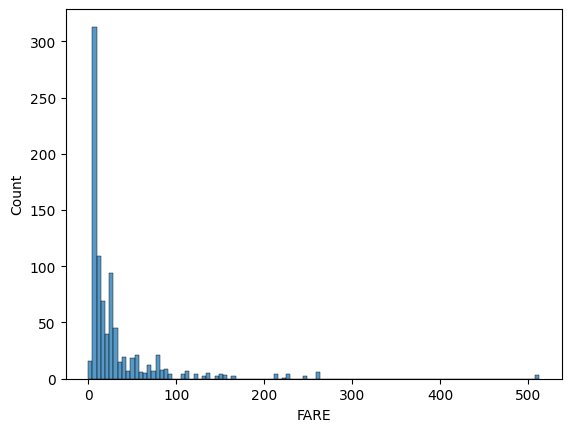

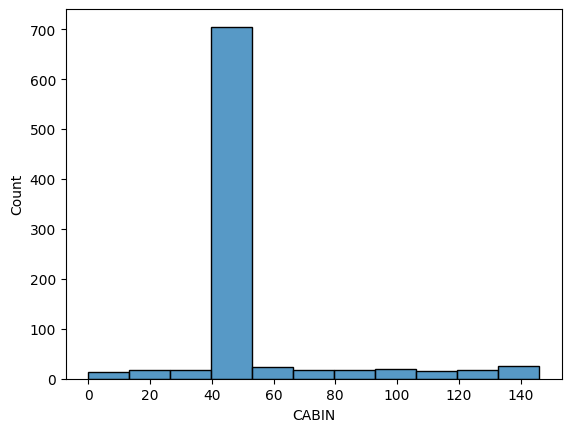

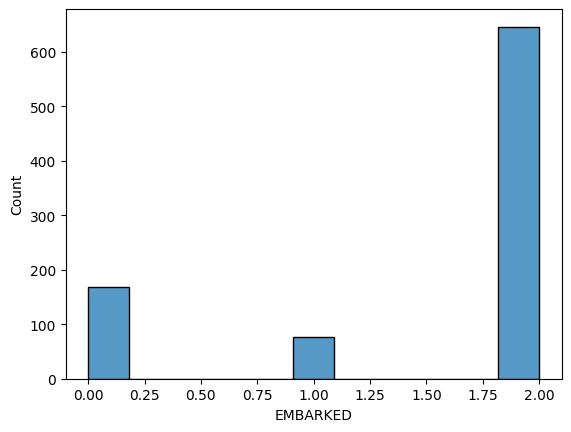

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
categ = df.select_dtypes(include = np.number)
for cols in categ:
  plt.figure()
  sns.histplot(df[cols])
  plt.show()


In [ ]:
import pandas as pd
import numpy as np
numbers = df.select_dtypes(include = np.number).columns
for cols in numbers:
  Q1 = df[cols].quantile(0.25)
  Q3 = df[cols].quantile(0.75)
  IQR  = Q3 -Q1
  Lower_bound = Q1 - 1.5*IQR
  Upper_bound = Q3 + 1.5*IQR
  outliers = df[(df[cols] < Lower_bound) | (df[cols] > Upper_bound)]
  outliers



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
X = df.drop(['PCLASS'],axis =1)
y = df['PCLASS']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state =42)

In [ ]:
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))
print("classification_report:",classification_report(y_test,y_pred))


accuracy_score: 0.6983240223463687
confusion_matrix: [[32 10 11]
 [ 4 15 14]
 [ 6  9 78]]
classification_report:               precision    recall  f1-score   support

           1       0.76      0.60      0.67        53
           2       0.44      0.45      0.45        33
           3       0.76      0.84      0.80        93

    accuracy                           0.70       179
   macro avg       0.65      0.63      0.64       179
weighted avg       0.70      0.70      0.70       179

